# Data Augmentation

One common challenge in training image classification models is the gap between training accuracy and validation accuracy. When the validation accuracy remains noticeably lower than the training accuracy, it often indicates overfitting, meaning the model may be relying too heavily on patterns that appear in the training data but do not generalize well to new examples.

To improve robustness when dealing with unseen data, a common strategy is to increase the size and diversity of the training dataset. This can be achieved through data augmentation, a widely used technique in deep learning.

Data augmentation programmatically generates modified versions of existing images—for example through rotations, flips, shifts, or changes in brightness. Increasing the effective dataset size provides the model with more training examples, while increasing the variability in the data encourages the model to focus on the most relevant features for classification rather than memorizing specific patterns. As a result, models trained with augmented data often generalize better to new inputs.

Objectives

* Augment the ASL dataset
* Use the augmented data to train an improved model
* Save the well-trained model to disk for use in deployment

In [1]:
import torch
import torch.nn as nn
import pandas as pd
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

## Preparing the Data

In [4]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1
N_CLASSES = 25

train_df = pd.read_csv("sample_data/sign_mnist_train.csv")
valid_df = pd.read_csv("sample_data/sign_mnist_test.csv")

print(train_df['label'].unique())
print(train_df['label'].max())

class MyDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255  # Normalize values from 0 to 1
        x_df = x_df.reshape(-1, IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

n = 32
train_data = MyDataset(train_df)
train_loader = DataLoader(train_data, batch_size=n, shuffle=True)
train_N = len(train_loader.dataset)

valid_data = MyDataset(valid_df)
valid_loader = DataLoader(valid_data, batch_size=n)
valid_N = len(valid_loader.dataset)

[ 3  6  2 13 16  8 22 18 10 20 17 19 21 23 24  1 12 11 15  4  0  5  7 14]
24


## Model Creation

Creating a custom module requires extending the Module class and defining two methods:
__init__ — defines the module's properties, including its neural network layers. This allows having a model within a model.
forward — defines how the module processes incoming data from the previous connected layer. When using a Sequential model internally, the input can be passed directly into it as if making a prediction.
Convolutional neural networks follow a repeated sequence of layers, so creating a custom module allows encapsulating that pattern and reusing it as a single layer within the main model.

In [3]:
class MyConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p, flatten=False, img_size=None):
        kernel_size = 3
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        ]

        if flatten:
            layers.append(nn.Flatten())

        self.model = nn.Sequential(*layers)

        if flatten and img_size:
            pool_size = img_size // 2
            self.flattened_size = out_ch * pool_size * pool_size

    def forward(self, x):
        return self.model(x)

In [5]:

last_block = MyConvBlock(50, 75, 0, flatten=True, img_size=7)  # entra 7x7

base_model = nn.Sequential(
    MyConvBlock(IMG_CHS, 25, 0),
    MyConvBlock(25, 50, 0.2),
    last_block,
    nn.Linear(last_block.flattened_size, 512),  # usa el tamaño calculado
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, N_CLASSES)
)

When we print the model, not only will it now show the use of our custom module, it will also show the layers within our custom module:

In [6]:
print(base_model)

Sequential(
  (0): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (1): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (2): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, 

In [7]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(base_model.parameters())

model = torch.compile(base_model.to(device))

Custom modules are flexible, and we can define any other methods or properties we wish to have. This makes them powerful when data scientists are trying to solve complex problems.

## Data Augmentation


Before defining the training loop, it is necessary to establish the data augmentation strategy. Please go to [TorchVision](https://pytorch.org/vision/stable/index.html) and transformation utilities [Transforms](https://docs.pytorch.org/vision/0.9/transforms.html)


In [10]:
row_0 = train_df.head(1)
y_0 = row_0.pop('label')
x_0 = row_0.values / 255
x_0 = x_0.reshape(IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
x_0 = torch.tensor(x_0)
x_0.shape

torch.Size([1, 28, 28])

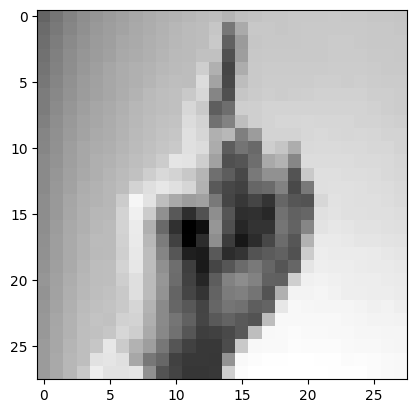

In [ ]:
image = F.to_pil_image(x_0)
plt.imshow(image, cmap='gray')

## [RandomResizeCrop](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomResizedCrop)

This transform will randomly resize the input image based on `scale`, and then [crop](https://en.wikipedia.org/wiki/Cropping_(image)) it to a size we specify. In this case, we will crop it to the original image dimensions. To do this, TorchVision needs to know the [aspect ratio](https://en.wikipedia.org/wiki/Aspect_ratio_(image)) of the image it is scaling. Since our height is the same as our width, our aspect `ratio` is 1:1.

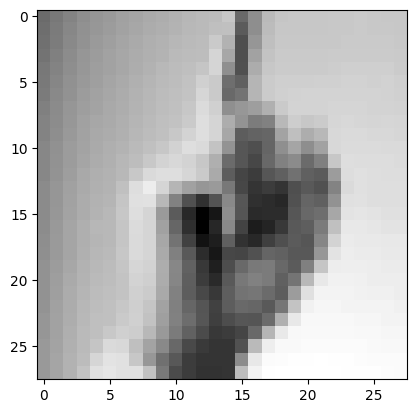

In [ ]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

### [RandomHorizontalFlip](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip)

In image augmentation, transformations such as horizontal and vertical flipping are often used to increase the variability of the training data. However, not all transformations are appropriate for every application.

Consider the case of sign language recognition. Would it be reasonable to apply both horizontal and vertical flips to these images? Reflect on how each transformation might affect the semantic meaning of the gesture before proceeding.

In practice, horizontal flipping can be appropriate because many gestures in American Sign Language can be performed with either the left or the right hand. In contrast, vertically flipping the image would produce gestures that appear upside down, a configuration that does not correspond to realistic observations of sign language.

This example illustrates an important principle in data augmentation: transformation choices should be guided by domain knowledge, ensuring that augmented samples remain physically and semantically meaningful.  [Horizontally](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip) or [Vertically](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomVerticalFlip).

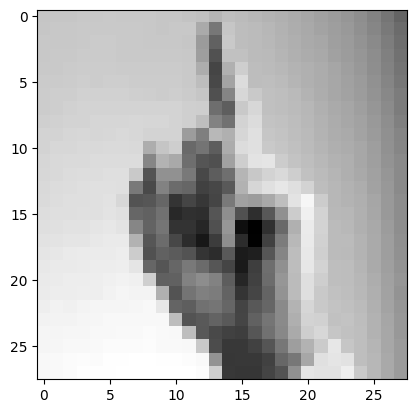

In [ ]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

## [RandomRotation](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomRotation)

Random rotation adds more variability to the training data. However, with ASL it's important not to rotate too much — excessive rotation can make one letter look like another (e.g. D rotated too far resembles a G). For this reason, rotation should be kept to a small range like ±10°.

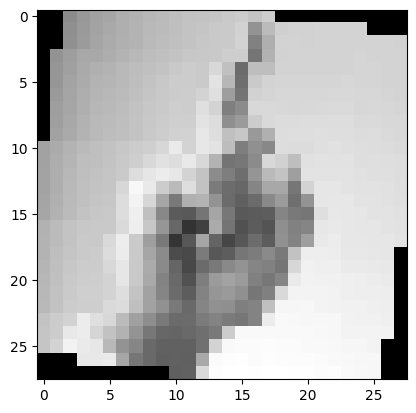

In [ ]:
trans = transforms.Compose([
    transforms.RandomRotation(10)
])
new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

## [ColorJitter](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.ColorJitter)

The `ColorJitter` transform has 4 arguments:
* [brightness]
* [contrast]
* [saturation]
* [hue]

The latter 2 apply to color images, so we will only use the first 2 for now.

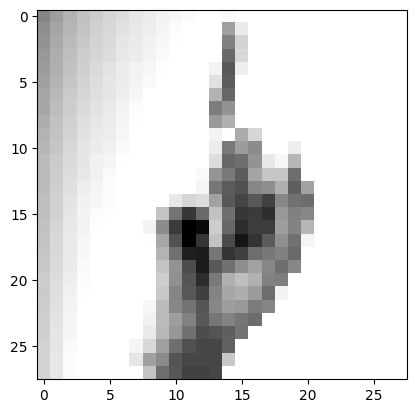

In [ ]:
brightness = .9  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

new_x_0 = trans(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

##Compose

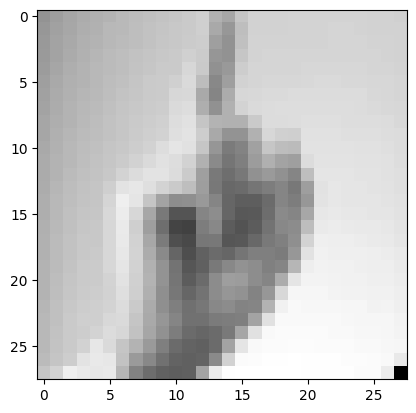

In [11]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

new_x_0 = random_transforms(x_0)
image = F.to_pil_image(new_x_0)
plt.imshow(image, cmap='gray')

## Batch Accuracy
During training it is often useful to monitor how well the model is performing on a batch of samples. A common metric for classification tasks is accuracy, which measures the proportion of correctly predicted labels

In [12]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

### Training with Augmentation

The training procedure remains largely unchanged. However, one modification is introduced: before the images are passed to the model, a set of random_transforms is applied. These transformations perform data augmentation, allowing the model to be exposed to variations of the training images.

In [13]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(random_transforms(x))  # Updated
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [14]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

Let's put data augmentation to the test.

In [15]:
epochs = 20

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0


W0305 13:15:43.970000 2308 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Train - Loss: 680.1531 Accuracy: 0.7424
Valid - Loss: 67.8448 Accuracy: 0.8947
Epoch: 1
Train - Loss: 100.5571 Accuracy: 0.9627
Valid - Loss: 24.7386 Accuracy: 0.9610
Epoch: 2
Train - Loss: 58.6101 Accuracy: 0.9787
Valid - Loss: 35.7445 Accuracy: 0.9431
Epoch: 3
Train - Loss: 40.8210 Accuracy: 0.9844
Valid - Loss: 17.6900 Accuracy: 0.9690
Epoch: 4
Train - Loss: 37.6249 Accuracy: 0.9869
Valid - Loss: 27.5128 Accuracy: 0.9520
Epoch: 5
Train - Loss: 30.2193 Accuracy: 0.9889
Valid - Loss: 40.7410 Accuracy: 0.9352
Epoch: 6
Train - Loss: 26.6052 Accuracy: 0.9899
Valid - Loss: 13.1085 Accuracy: 0.9780
Epoch: 7
Train - Loss: 22.7191 Accuracy: 0.9917
Valid - Loss: 22.2003 Accuracy: 0.9732
Epoch: 8
Train - Loss: 22.1818 Accuracy: 0.9919
Valid - Loss: 13.5943 Accuracy: 0.9805
Epoch: 9
Train - Loss: 17.4910 Accuracy: 0.9934
Valid - Loss: 15.7622 Accuracy: 0.9828
Epoch: 10
Train - Loss: 19.4138 Accuracy: 0.9931
Valid - Loss: 11.0089 Accuracy: 0.9875
Epoch: 11
Train - Loss: 13.5586 Accuracy: 0.9950


## Saving the Model

Once the model has been trained and validated, the next step is to use it for inference on previously unseen images. A common practice is to serialize the trained parameters to disk so that the model can be restored later without repeating the training process. [Save models](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [18]:
torch.save(base_model, 'model.pth')
torch.save(base_model.state_dict(), 'model_weights.pth')

## Summary

In this section, you used TorchVision to augment a dataset. This resulted in a trained model with less overfitting and excellent validation image results.

### Clear the Memory
Before moving on, please execute the following cell to clear up the GPU memory.

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)